### Tikohonv-Fenichel parameter values for some epidemiology models

$$
\newcommand{\cR}{\mathcal{R}}
\newcommand{\cX}{\mathcal{X}}
\newcommand{\cY}{\mathcal{Y}}
\newcommand{\bN}{\mathbb{N}}
\newcommand{\bR}{\mathbb{R}}
$$

Consider the mass-action chemical reaction network $G=(\cY,\cR,\kappa).$ Where $\cY$ is the set of complexes formed with the elements of the species set $\cX=\left\{X_1,\dots,X_n\}\right\}$, $\cR$ is the set of reactions and $\kappa$ is the set of reaction rates which label the reactions. Let $m=|\cR|$ and $d=|\cY|.$ A complex $Y$ will be of the form $Y=\sum_{i=1}^n y_{ij}X_j$ with $k_{ij} \in \bN.$ $y_{ij}$ will be called stoichiometric coefficients. A reaction will look like
$$
Y_j \xrightarrow{k_{lj}} Y_l.
$$
$Y_j$ is called the reactant and $Y_l$ the product complex. If one puts an order on $\cR$ and number the reactions, then we can identify the coefficients $k_{lj}$ with the elements of a vector $k \in \bR_{>0}^m$ and denote with $k_i$ the coefficients of the $i$th reaction. 

Let now $x(t)=\left(x_1(t),\dots,x_n(t)\right)$ be the vector of concentrations at time $t$. Define the matrix $Y=\left( y_{ij}\right)_{1 \leq i \leq n, 1 \leq j \leq d}$ with columns $y_1,\dots,y_d.$ Let $B$ be the matrix whose $i$ column is $y_j$  if $Y_j$ is a reactant in the $i$-th reaction and $N$ the matrix whose $i$-th column is $y_l-y_j$ if the respective reaction is $Y_j \to Y_l.$ The system of ODEs modelling the evolution of concentrations is 
$$
x' = N \text{diag}(\kappa)x^B,
$$
where $x^B=(x^{y_1},\dots,x^{y_m})$ and for two vectors $x=(x_1,\dots,x_n)$ and $y=(y_1,\dots,y_n),$ $x^y:=x_1^{y_1}\cdots
x_n^{y_n}.$

Another representation of the system of ODEs is 
$$
x' = Y A(\kappa)x^Y,
$$
where $A(\kappa)$ is the Laplacean matrix of the reaction network. Its components are $a_{ij}=k_{ij}$ and $a_{jj}=
-\sum_{k\neq l}k_{lj}$. If there is no reaction $Y_i \to Y_j$ then $k_{ij}=0.$

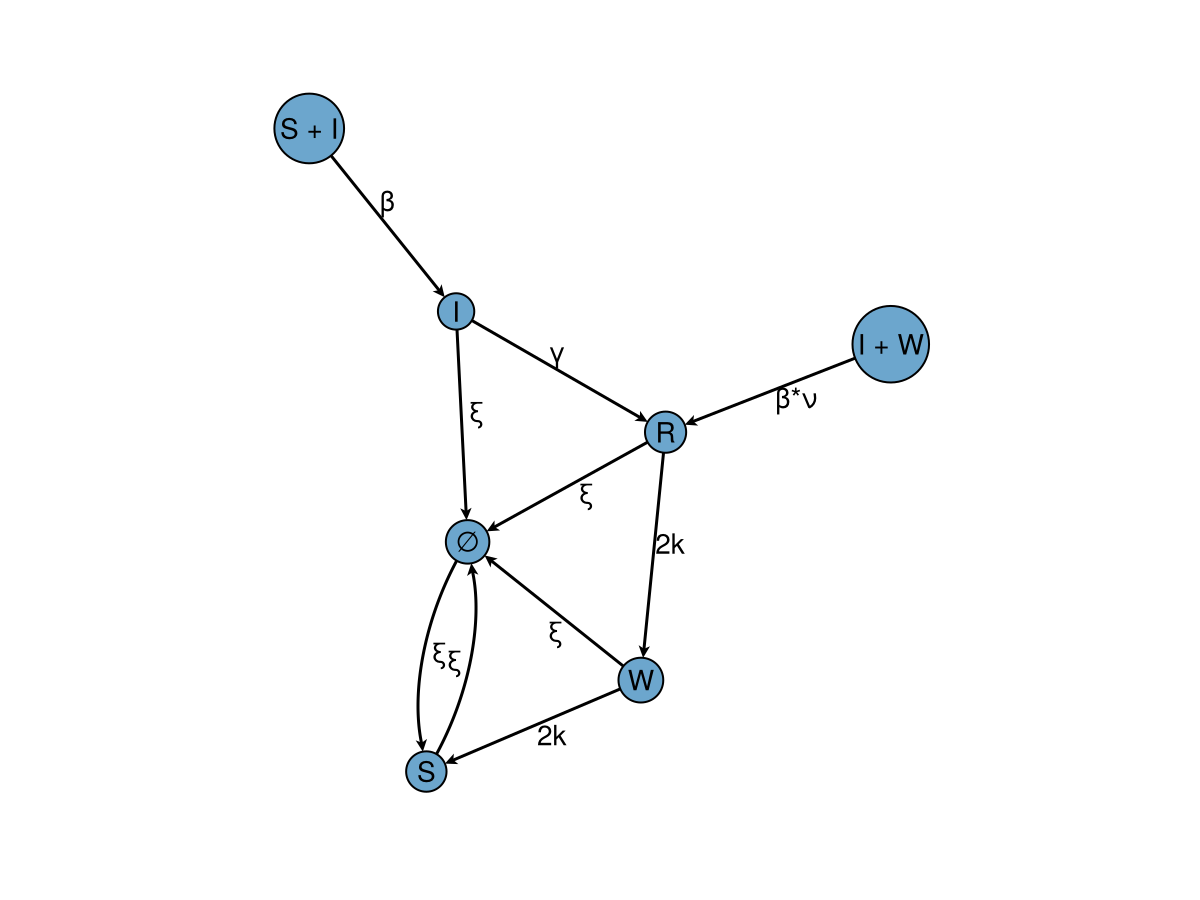

In [32]:
using Catalyst
# using Oscar
using GraphMakie, NetworkLayout
using CairoMakie

sirws = @reaction_network begin
    ξ, 0 --> S
    ξ, S --> 0
    ξ, I --> 0
    ξ, R --> 0
    ξ, W --> 0
    β, S + I --> I
    γ, I --> R
    2*k, R --> W
    ν*β, W + I --> R
    2*k, W --> S
end
# osys = convert(ODESystem, sirws)
# equations(osys)
plot_complexes(sirws,show_rate_labels=true)

In [33]:
 osys = convert(ODESystem, sirws)
 equations(osys)

4-element Vector{Equation}:
 Differential(t)(S(t)) ~ ξ + 2k*W(t) - S(t)*ξ - S(t)*I(t)*β
 Differential(t)(I(t)) ~ -I(t)*γ - I(t)*ξ - W(t)*I(t)*β*ν
 Differential(t)(R(t)) ~ -2k*R(t) - R(t)*ξ + I(t)*γ + W(t)*I(t)*β*ν
 Differential(t)(W(t)) ~ 2k*R(t) - 2k*W(t) - W(t)*ξ - W(t)*I(t)*β*ν

In [31]:
 osys = convert(ODESystem, sirws_rn)
 equations(osys_rn)

4-element Vector{Equation}:
 Differential(t)(S(t)) ~ ξ + 2k*W(t) - S(t)*ξ - I(t)*β
 Differential(t)(I(t)) ~ I(t)*β - I(t)*γ - I(t)*ξ
 Differential(t)(R(t)) ~ -2k*R(t) - R(t)*ξ + I(t)*γ + I(t)*β*ν
 Differential(t)(W(t)) ~ 2k*R(t) - 2k*W(t) - W(t)*ξ - I(t)*β*ν

Equation[Differential(t)(S(t)) ~ ξ + 2k*W(t) - S(t)*ξ - S(t)*I(t)*β, Differential(t)(I(t)) ~ -I(t)*γ - I(t)*ξ - W(t)*I(t)*β*ν, Differential(t)(R(t)) ~ -2k*R(t) - R(t)*ξ + I(t)*γ + W(t)*I(t)*β*ν, Differential(t)(W(t)) ~ 2k*R(t) - 2k*W(t) - W(t)*ξ - W(t)*I(t)*β*ν]

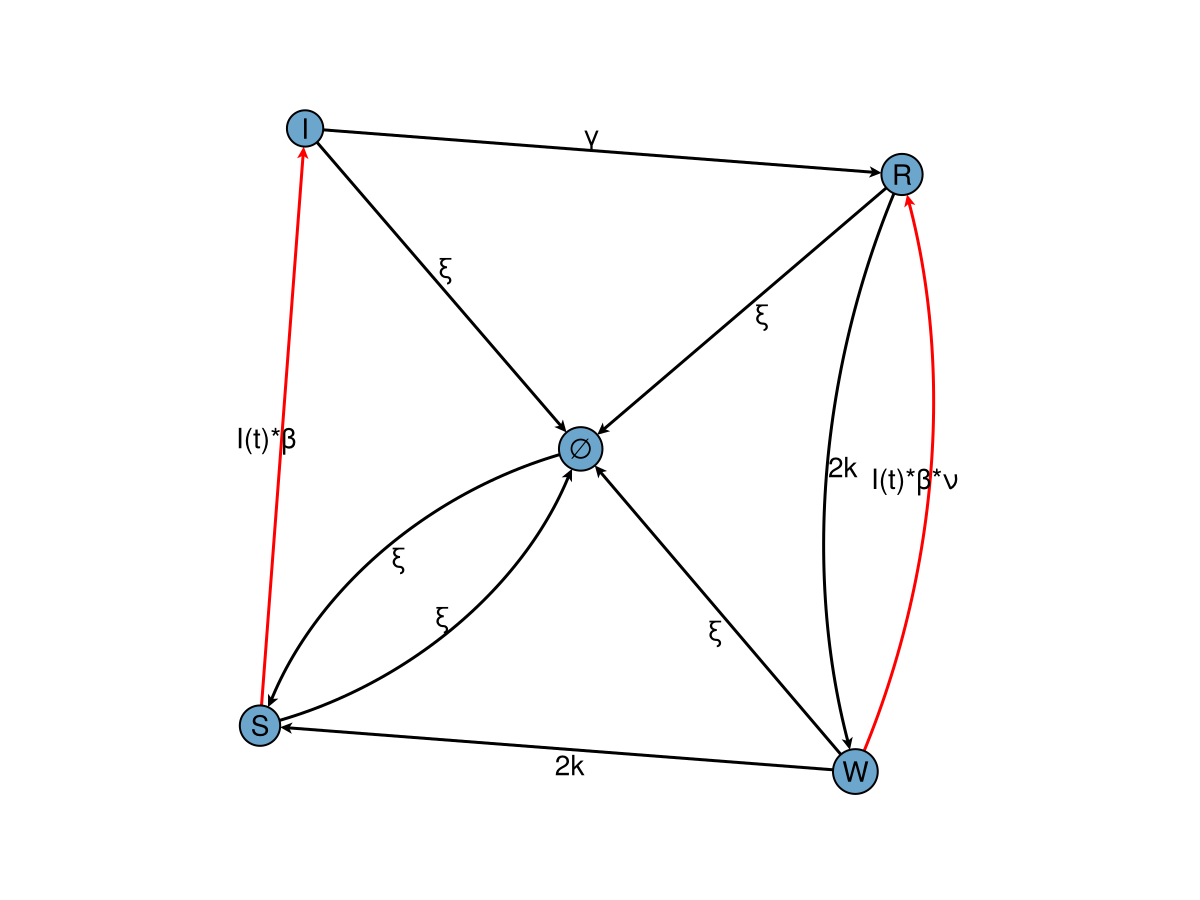

In [30]:
using Catalyst
# using Oscar
using GraphMakie, NetworkLayout
using CairoMakie

t=default_t()
@parameters ξ, β, γ, k, ν
@species S(t), I(t), R(t), W(t)
rxs_sirws = [ Reaction(ξ, nothing,[S]),
           Reaction(ξ, [S], nothing),
    Reaction(ξ, [I], nothing),
    Reaction(ξ, [R], nothing),
    Reaction(ξ, [W], nothing),
    Reaction(β*I,[S],[I];only_use_rate=true),
    Reaction(γ,[I],[R]),
    Reaction(2*k,[R],[W]),
    Reaction(ν*β*I,[W],[R];only_use_rate=true),
    Reaction(2*k,[W],[S])]
@named sirws_rn=ReactionSystem(rxs_sirws)
# osys = convert(ODESystem, sirws)
# equations(osys)
sirws_rn = complete(sirws_rn)
osys = convert(ODESystem, sirws)
print(equations(osys))
plot_complexes(sirws_rn,show_rate_labels=true)